# Entregável 3 — Análise Estatística Inicial da Base

**Disciplina:** Aquisição e Processamento de Biossinais  
**Equipe:** José Ferreira Lessa & Matheus Rocha Gomes da Silva  
**Orientador:** Prof. Dr. Victor Hugo C. de Albuquerque  
**Dataset:** PTB-XL — A Large Publicly Available Electrocardiography Dataset (PhysioNet)  
**Referência:** Wagner et al. (2020). PTB-XL, a large publicly available electrocardiography dataset. *Scientific Data*, 7(1), 154.  
**Data:** Março e Abril de 2026

---

## Objetivo

Este notebook descreve a etapa de **Análise Estatística** do dataset. No entregável 1, já foi feita uma análise exploratória e descritiva básica que permitiu entender o que existe no dataset. A estatística lá tinha como foco a caracterização; responder à pergunta: "o que eu tenho nas mãos?". Agora, no entregável 3, essa análise será inferencial/metodológica, ou seja, servirá como base para decisões futuras, procurando qualificar estatisticamente os dados e definir a metodologia analítica para o restante do projeto. Por isso, terá como foco responder à pergunta: "quais são os pressupostos dos meus dados e que ferramentas posso usar?". Sendo assim, este notebook é composto pelas seguintes seções:

1. **Estatística Descritiva dos Metadados:** Distribuição das variáveis demográficas (idade, peso, altura) para o dataset completo e estratificadas por superclasse diagnóstica; análise da evolução temporal das coletas.
2. **Estatística Descritiva dos Sinais:** Métricas de amplitude (RMS e pico a pico) e energia total calculadas por derivação e por superclasse, com base em amostra estratificada.
3. **Testes de Normalidade:** Shapiro-Wilk e Kolmogorov-Smirnov para verificação do pressuposto de distribuição normal; Q-Q Plots para inspeção visual.
4. **Testes de Homocedasticidade:** Levene e Bartlett para verificação de igualdade de variâncias entre grupos diagnósticos.
5. **Análise de Correlação:** Matrizes de correlação de Pearson e Spearman entre variáveis demográficas, métricas do sinal e SQI.
6. **Síntese e Conexão:** Tabela-decisão metodológica e conexão com os entregáveis seguintes.

## 1. Importações, Configurações e Dependências

Neste entregável, utilizamos as mesmas bibliotecas já utilizadas nos entregáveis anteriores, sem nenhuma adição.

In [1]:
import os
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import wfdb
import scipy.signal as signal
import scipy.stats as stats       
from pathlib import Path              
from tqdm import tqdm
from IPython.display import display, Markdown
import warnings

warnings.filterwarnings('ignore', category=UserWarning)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

np.random.seed(42)

## 2. Configurações Globais

Aqui são definidas as constantes globais do projeto, que já foram definidas e justificadas nos entregáveis anteriores.

In [2]:
DATA_DIR = Path('../../../data/ptb-xl/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3/')
FS = 100
N_LEADS = 12
LEAD_NAMES = ['I', 'II', 'III', 'aVL', 'aVR', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
FOLDS_TREINO = [1, 2, 3, 4, 5, 6, 7, 8]
FOLD_VAL = 9
FOLD_TEST = 10

FIGS_DIR = Path('../figuras')
OUT_DIR  = Path('../outputs')
for d in [FIGS_DIR, OUT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print('Configuração concluída.')
print(f'Figuras em : {FIGS_DIR.resolve()}')
print(f'Outputs em : {OUT_DIR.resolve()}')

Configuração concluída.
Figuras em : C:\Users\User\Desktop\repo-lessa\entregaveis\entregavel-3\figuras
Outputs em : C:\Users\User\Desktop\repo-lessa\entregaveis\entregavel-3\outputs


## 3. Carregamento e Filtragem Inicial

Aqui, partimos do arquivo `ptbxl_com_sqi.csv` gerado pelo Entregável 2, que já contém todas as colunas do Entregável 1 (metadados enriquecidos, superclasses diagnósticas, ritmos, formas, splits) acrescidas das métricas SQI e da classificação de qualidade (`quality_class`: A, G, P ou U).

O primeiro passo é **remover os registros de Categoria U** — aqueles identificados como de baixa qualidade irrecuperável pelo sistema de avaliação SQI implementado no Entregável 2. Manter esses registros na análise introduziria viés estatístico, pois suas métricas de amplitude e morfologia são contaminadas por ruído ou artefatos e não representam a atividade cardíaca real.

Algumas colunas foram serializadas como strings no CSV (listas e dicionários Python); é necessário fazer o parse correto com `ast.literal_eval` antes de usá-las.

In [3]:
caminho_metadados = '../../entregavel-2/outputs/ptbxl_com_sqi.csv'

if not os.path.exists(caminho_metadados):
    raise FileNotFoundError(
        f"Arquivo ptbxl_com_sqi.csv não encontrado em: {caminho_metadados}\n"
        "Execute o Entregável 2 primeiro."
    )

df = pd.read_csv(caminho_metadados, index_col='ecg_id')

# Reconversão de colunas serializadas como string
df['scp_codes']        = df['scp_codes'].apply(ast.literal_eval)
df['superclasses_clean'] = df['superclasses_clean'].apply(ast.literal_eval)  # nome correto do Entregável 1
df['recording_date']   = pd.to_datetime(df['recording_date'], errors='coerce')

tam_original = len(df)
df = df[df['quality_class'].isin(['A', 'G', 'P'])].copy()

# Remove colunas que foram auxiliares na análise final do Entregável 2, mas agora não mais são úteis
df = df.drop(columns=['is_good', 'is_bad'], errors='ignore')

display(Markdown(
    f"Dataset carregado do Entregável 2.  \n"
    f"Removidos **{tam_original - len(df)}** registros de Categoria U (Unacceptable).  \n"
    f"Trabalhando com **{len(df)}** registros aprovados (categorias G, A e P)."
))

Dataset carregado do Entregável 2.  
Removidos **1959** registros de Categoria U (Unacceptable).  
Trabalhando com **19840** registros aprovados (categorias G, A e P).

---

## Seção 1 — Estatística Descritiva dos Metadados

### 1.1 Variáveis Demográficas

Antes de qualquer teste inferencial, vamos rever algumas variáveis demográficas (Idade, peso e altura) que já foram vistas no entregável 1, a fim de analisar como está o comportamento do dataset após remover os dados de classe U e também para reafirmar os resultados adquiridos e tirar novas conclusões a partir disso.

**Tabela descritiva: N, média, mediana, desvio padrão, percentis e IQR.**

,count,mean,std,min,5%,25%,75%,95%,max,IQR,Variância
age_clean,19581.0,59.71,16.65,3.0,27.0,50.0,72.0,84.0,89.0,22.0,277.10
weight,8345.0,70.98,15.78,5.0,50.0,60.0,80.0,96.0,250.0,20.0,249.14
height,6188.0,166.66,10.84,6.0,152.0,160.0,174.0,183.0,209.0,14.0,117.53


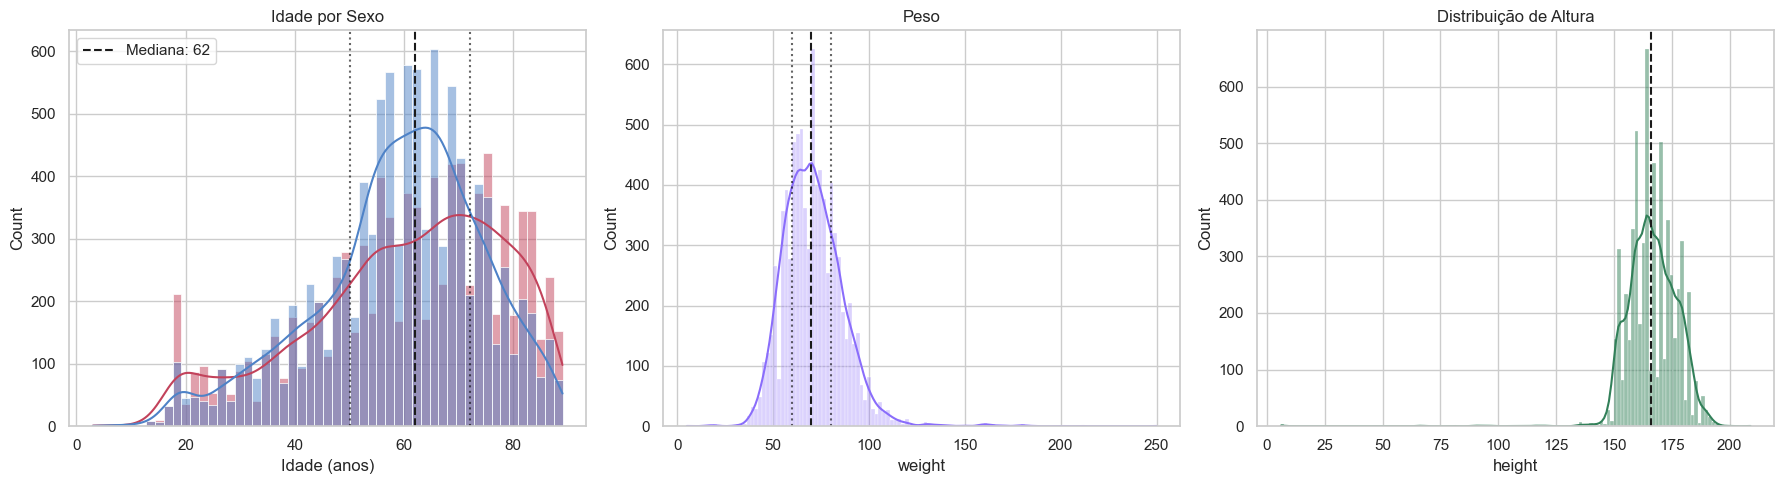

In [4]:
# Reanálise das Variáveis Demográficas

df['age_clean'] = df['age'].replace(300, np.nan)

vars_desc = ['age_clean', 'weight', 'height']
stats_demo = df[vars_desc].describe(percentiles=[0.05, 0.25, 0.75, 0.95]).T
stats_demo['IQR']       = stats_demo['75%'] - stats_demo['25%']
stats_demo['Variância'] = df[vars_desc].var()

display(Markdown("**Tabela descritiva: N, média, mediana, desvio padrão, percentis e IQR.**"))
display(stats_demo.round(2))

# Plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(data=df, x='age_clean', hue='sex', kde=True,
             ax=axes[0], palette=['#4e82c7', '#c2425b'], alpha=0.5)
axes[0].axvline(df['age_clean'].median(), color='k', linestyle='--',
                label=f"Mediana: {df['age_clean'].median():.0f}")
axes[0].axvline(df['age_clean'].quantile(0.25), color='black', linestyle=':', alpha=0.6)
axes[0].axvline(df['age_clean'].quantile(0.75), color='black', linestyle=':', alpha=0.6)
axes[0].set_title('Idade por Sexo')
axes[0].set_xlabel('Idade (anos)')
axes[0].legend()

sns.histplot(data=df, x='weight', color='#8a6dfb', kde = True, ax=axes[1], alpha = 0.3)
axes[1].axvline(df['weight'].median(), color='k', linestyle='--',
                label=f"Mediana: {df['weight'].median():.0f}")
axes[1].axvline(df['weight'].quantile(0.25), color='black', linestyle=':', alpha=0.6)
axes[1].axvline(df['weight'].quantile(0.75), color='black', linestyle=':', alpha=0.6)
axes[1].set_title('Peso')

sns.histplot(data=df, x='height', kde=True, ax=axes[2], color='#328059', alpha=0.5)
axes[2].axvline(df['height'].median(), color='k', linestyle='--')
axes[2].set_title('Distribuição de Altura')

plt.tight_layout()
fig.savefig(FIGS_DIR / 'descritiva_demografica.png', dpi=150, bbox_inches='tight')
plt.show()

**Comentários sobre a subseção 1.1:**

Analisando a aparência dos gráficos acima e comparando-os aos gerados durante o Entregável 1, vemos que as alterações foram mínimas e localizadas em valores tão diversos que poderíamos dizer que, na prática, essas variáveis não sofreram impacto algum da exclusão dos sinais classificados como U: portanto, a análise anteriormente feita continuar válida. 

Podemos ver que outliers absurdos e completamente sem sentido (como o indivíduo de peso 5kg e o de altura 6cm) acabaram por passar pelo filtro do SQI, o que poderia ser um problema para análise de tendências por peso/altura: contudo, nosso foco até agora foi puramente ter sinais de ECG coerentes e valiosos para nosso futuro modelo de diagnóstico. Com isso, esses outliers podem continuar a serem aceitos por enquanto.

### 1.2 Variáveis Demográficas por Superclasse Diagnóstica

A análise anterior tratou o dataset como um todo. Aqui, estratificamos as mesmas variáveis demográficas pelas **5 superclasses diagnósticas** (NORM, MI, CD, STTC, HYP) para identificar padrões clínicos entre grupos.

Para evitar ambiguidade decorrente do caráter **multi-label** do PTB-XL (um registro pode pertencer a mais de uma superclasse), filtramos apenas os registros com **exatamente uma superclasse associada** (`n_superclasses == 1`). Dessa forma, garantimos que cada observação pertence de forma inequívoca a um único grupo diagnóstico, tornando a comparação entre grupos estatisticamente válida.

A visualização de boxplots sobrepostos permite identificar se existem diferenças sistemáticas de idade entre as patologias — o que seria esperado clinicamente, já que doenças como infarto do miocárdio (MI) e hipertrofia (HYP) costumam manifestar-se em faixas etárias mais avançadas.

In [5]:
# Função auxiliar para plotar os gráficos desejados

def plot_box_com_quartis(df, var, ylabel, titulo, filename):
    fig = plt.figure(figsize=(10, 6))

    ax = sns.boxplot(
        data=df,
        x='single_class',
        y=var,
        order=classes_target,
        hue='single_class',
        palette='Set2',
        legend=False
    )

    # Quartis
    quartis = df.groupby('single_class')[var].quantile([0.25, 0.5, 0.75]).unstack().reindex(classes_target)
 
    # Anotações
    for i, classe in enumerate(classes_target):
        if classe not in quartis.index:
            continue

        q1 = quartis.loc[classe, 0.25]
        med = quartis.loc[classe, 0.5]
        q3 = quartis.loc[classe, 0.75]

        x = i + 0.25

        ax.text(x, q1, f'Q1 ={q1:.1f}', ha='center', va='top', fontsize=8, fontweight='bold')
        ax.text(x, med, f'Med ={med:.1f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
        ax.text(x, q3, f'Q3 ={q3:.1f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

    plt.title(titulo)
    plt.xlabel('Superclasse')
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.savefig(FIGS_DIR / filename, dpi=150, bbox_inches='tight')
    plt.show()

**Estatísticas separadas por diagnóstico:**

age_clean                         weight                          \
                median  mean   std    Q1    Q3 median  mean   std    Q1    Q3   
single_class                                                                    
CD                65.5  63.7  15.7  55.0  75.0   70.0  71.7  15.1  62.0  80.0   
HYP               64.0  61.6  15.5  53.0  73.0   70.0  70.3  14.4  60.0  79.0   
MI                64.0  64.0  12.5  56.0  73.0   73.0  74.6  18.9  62.0  84.0   
NORM              54.0  52.2  17.2  40.0  65.0   70.0  71.2  14.9  60.0  80.0   
STTC              65.0  64.2  14.2  55.0  75.0   70.0  71.2  17.0  60.0  80.0   

             height                             
             median   mean   std     Q1     Q3  
single_class                                    
CD            168.0  167.3  12.5  160.0  175.0  
HYP           168.0  167.0  10.0  160.0  174.2  
MI            168.0  166.8  12.3  160.0  174.0  
NORM          166.0  166.9  10.6  160.0  174.0  
STTC          165.0  165.5   9.4  159.0  172.0

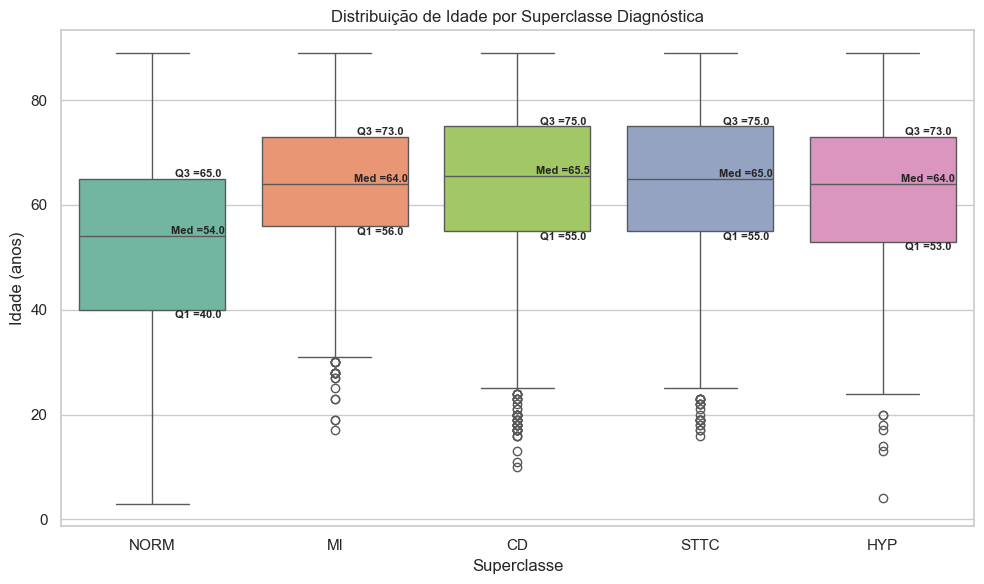

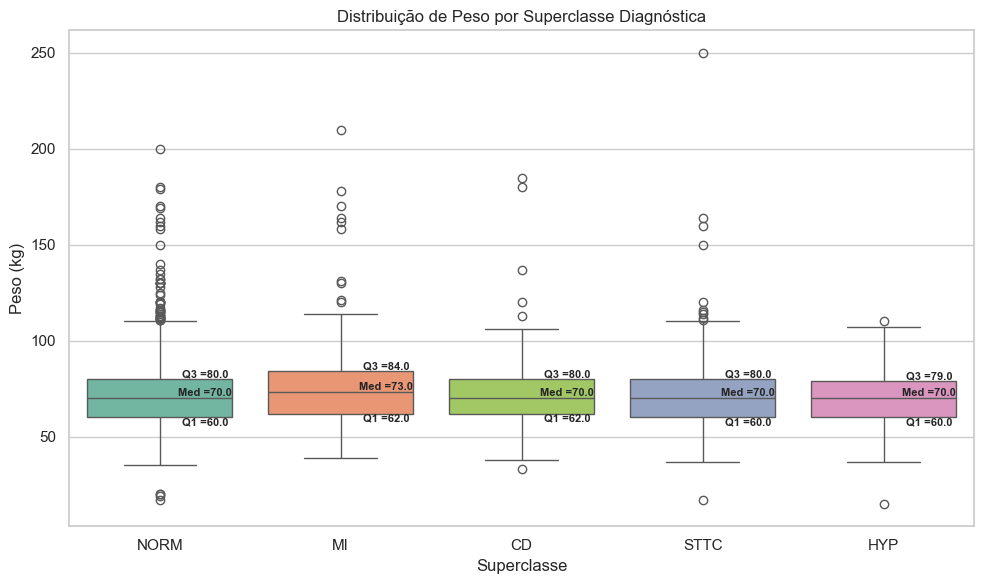

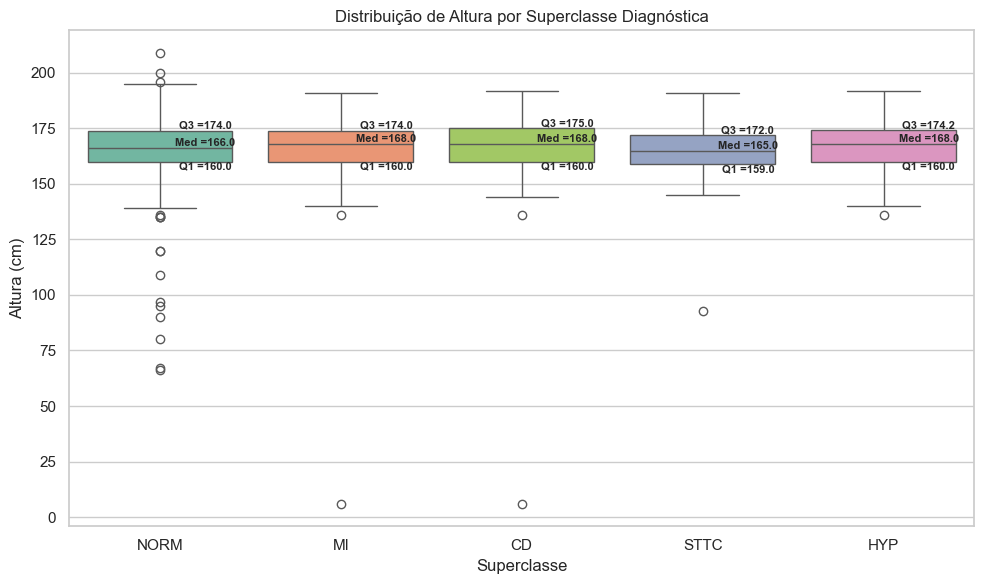

In [6]:
# Plot de Distribuição de Variáveis Demográficas por Superclasse Diagnóstica

df_single = df[df['n_superclasses'] == 1].copy()
df_single['single_class'] = df_single['superclasses_clean'].apply(lambda x: x[0])
classes_target = ['NORM', 'MI', 'CD', 'STTC', 'HYP']

def Q1(x): return x.quantile(0.25)
def Q3(x): return x.quantile(0.75)

pivot_diag = df_single.groupby('single_class')[vars_desc].agg(['median', 'mean', 'std', Q1, Q3])
display(Markdown("**Estatísticas separadas por diagnóstico:**"))
display(pivot_diag.round(1))

plot_box_com_quartis(df_single,var='age_clean',ylabel='Idade (anos)',titulo='Distribuição de Idade por Superclasse Diagnóstica',filename='idade_por_superclasse.png')

plot_box_com_quartis(df_single,var='weight',ylabel='Peso (kg)',titulo='Distribuição de Peso por Superclasse Diagnóstica',filename='peso_por_superclasse.png')

plot_box_com_quartis(df_single,var='height',ylabel='Altura (cm)',titulo='Distribuição de Altura por Superclasse Diagnóstica',filename='altura_por_superclasse.png')

**Comentários sobre a subseção 1.2:**
A estratificação das variáveis demográficas por superclasse diagnóstica revela padrões consistentes, especialmente em relação à idade dos pacientes.

**Idade (age_clean):**
Observa-se uma diferença clara entre o grupo **NORM** e as demais superclasses. Enquanto pacientes classificados como NORM apresentam mediana de **54 anos** (Q1 = 40, Q3 = 65), as classes patológicas (**MI, CD, STTC e HYP**) concentram-se em faixas etárias mais elevadas, com medianas em torno de **64–65 anos**. Essa separação de aproximadamente 10 anos sugere um padrão consistente de associação entre envelhecimento e presença de alterações cardíacas, em linha com o conhecimento clínico sobre a progressão de doenças cardiovasculares.

**Peso (weight):**
As distribuições de peso são bastante semelhantes entre as classes, com medianas próximas de **70–73 kg**. A classe **MI** apresenta uma média ligeiramente superior (**74.6 kg**) e maior variabilidade (desvio padrão de 18.9), o que pode refletir maior heterogeneidade entre os pacientes desse grupo. No entanto, a elevada sobreposição entre as distribuições indica que o peso, isoladamente, possui baixo poder discriminativo entre as superclasses.

**Altura (height):**
As distribuições de altura são praticamente idênticas entre todos os grupos, com medianas entre **165 e 168 cm** e desvios padrão semelhantes. Não se observa qualquer tendência associada ao diagnóstico, sugerindo que essa variável não contribui de forma relevante para a distinção entre as superclasses.

**Síntese:**
De forma geral, a **idade** se destaca como a variável demográfica mais informativa, apresentando diferenças sistemáticas entre indivíduos saudáveis e pacientes com patologias cardíacas. Em contraste, **peso e altura** demonstram baixa capacidade discriminativa quando analisados isoladamente, embora possam adquirir relevância quando combinados em métricas derivadas, como o índice de massa corporal (IMC).


### 1.3 Distribuição Temporal dos Registros

O PTB-XL foi coletado ao longo de vários anos em contexto hospitalar. Analisar a evolução temporal dos registros é relevante por dois motivos:

1. **Representatividade ao longo do tempo:** um volume de coleta muito heterogêneo entre anos pode introduzir viés caso haja mudanças nas práticas clínicas ou nos equipamentos utilizados.
2. **Evolução do uso de laudos automáticos:** a proporção de laudos gerados automaticamente pelo equipamento (campo `initial_autogenerated_report`) em relação aos laudos manuais pode variar ao longo do tempo, refletindo a adoção crescente de tecnologias de análise automática de ECG.

O gráfico usa eixo duplo: barras para o volume de registros (eixo esquerdo) e linha para a taxa percentual de laudos automáticos (eixo direito).

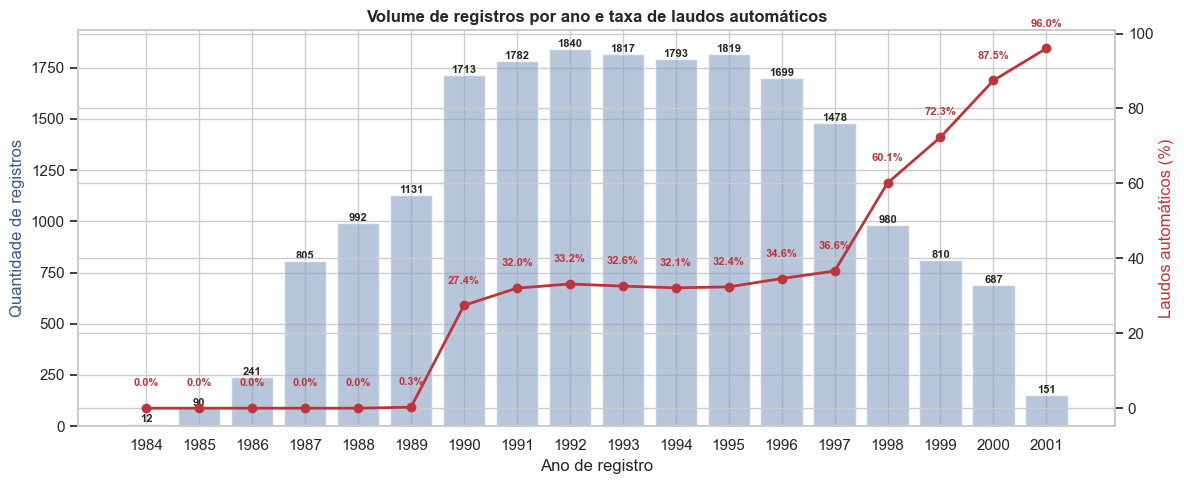

In [7]:
# Plot da análise de evolução temporal da coleta de registros

fig, ax1 = plt.subplots(figsize=(12, 5))

# -------------------------
# Preparar dados
# -------------------------
anos = df['recording_date'].dt.year
anos_range = range(int(anos.min()), int(anos.max()) + 1)

counts = anos.value_counts().sort_index().reindex(anos_range, fill_value=0)

# -------------------------
# Histograma (quantidade de registros)
# -------------------------
bars = ax1.bar(
    counts.index,
    counts.values,
    color='#8aa1c4',
    alpha=0.6
)

ax1.set_xlabel('Ano de registro')
ax1.set_ylabel('Quantidade de registros', color='#3a5c8c')
ax1.set_xticks(list(anos_range))  

# Anotações nas barras
for bar in bars:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{int(height)}',
        ha='center',
        va='bottom',
        fontsize=8,
        fontweight='bold'
    )

# -------------------------
# Linha (% de laudos automáticos)
# -------------------------
ax2 = ax1.twinx()

taxa_auto = (
    df.groupby(df['recording_date'].dt.year)['initial_autogenerated_report']
    .mean()
    .reindex(anos_range) * 100
)

ax2.plot(
    taxa_auto.index,
    taxa_auto.values,
    color='#bd353a',
    marker='o',
    linewidth=2
)

ax2.set_ylabel('Laudos automáticos (%)', color='#bd353a')

# Anotações na linha
y_range = ax2.get_ylim()[1] - ax2.get_ylim()[0]

for x, y in zip(taxa_auto.index, taxa_auto.values):
    if not np.isnan(y):
        ax2.text(
            x,
            y + 0.05 * y_range,  # 3% da escala do eixo
            f'{y:.1f}%',
            ha='center',
            va='bottom',
            fontsize=8,
            color='#bd353a',
            fontweight='bold'
            
        )

# -------------------------
# Final
# -------------------------
plt.title('Volume de registros por ano e taxa de laudos automáticos', fontweight='bold')
plt.tight_layout()

fig.savefig(FIGS_DIR / 'temporal_coletas.png', dpi=150, bbox_inches='tight')
plt.show()

**Comentários sobre a subseção 1.3:**

A análise do gráfico temporal evidencia um crescimento acentuado no volume de registros de ECG ao longo do final da década de 1980 e, principalmente, durante os anos 1990. Esse aumento é acompanhado por mudanças importantes na proporção de exames com laudos automatizados, revelando diferentes fases de adoção tecnológica.

Observa-se inicialmente um **salto abrupto entre 1989 e 1990**, em que a taxa de laudos automáticos passa de aproximadamente **0,3% para 27,4%**. Esse comportamento indica uma rápida incorporação inicial de sistemas computacionais na análise de ECG, provavelmente impulsionada pela introdução de soluções digitais baseadas em PC — como as desenvolvidas por *Nasiff Associates* no final dos anos 1980 — que viabilizaram a digitalização, armazenamento e processamento automatizado dos sinais.

Entretanto, esse crescimento inicial não se manteve no mesmo ritmo ao longo da década. Entre **1990 e 1997**, observa-se uma **quase estagnação relativa**, com a proporção de laudos automáticos aumentando modestamente de **27,4% para 36,6%**. Esse período pode ser interpretado como uma fase de **transição e consolidação**, em que as tecnologias já introduzidas passam a ser gradualmente integradas à prática clínica, enfrentando possíveis barreiras como custo, adaptação de workflow e validação médica.

A partir de **1998**, ocorre uma nova inflexão marcante: a taxa de laudos automatizados salta para cerca de **60,1%**, indicando uma **segunda onda de adoção tecnológica**, possivelmente associada a melhorias nos algoritmos, maior confiabilidade dos sistemas e expansão da infraestrutura digital em saúde. Nos anos subsequentes, esse crescimento se acelera ainda mais, atingindo aproximadamente **96% em 2001**.

No entanto, é importante contextualizar esse último valor: em 2001, o número total de registros coletados é bastante reduzido (**apenas 151 registros**), o que sugere que essa alta taxa pode refletir um cenário mais controlado ou específico (por exemplo, uso direcionado de sistemas automatizados), e não necessariamente uma adoção massiva em larga escala comparável aos anos anteriores.

Em paralelo, o volume absoluto de registros mostra um padrão distinto: há um período de coleta intensiva durante os anos 1990, seguido por uma redução no final da década. Essa diminuição pode estar relacionada à maturidade do banco de dados já estabelecido, mudanças institucionais, ou redirecionamento de esforços clínicos e de pesquisa.

De forma geral, o gráfico revela não apenas a evolução quantitativa da coleta de ECG, mas também uma **adoção tecnológica em duas fases**:
1. **Introdução rápida (final dos anos 80 / início dos 90)**  
2. **Consolidação lenta seguida de aceleração (final dos anos 90 em diante)**  

Esse comportamento é consistente com padrões clássicos de difusão tecnológica em saúde, nos quais inovações passam por um período inicial de entusiasmo, seguido por adaptação gradual, antes de atingir maior maturidade e adoção ampla.

---

**Referências:**

- [Nasiff Associates — desenvolvimento de sistemas de ECG baseados em PC (final dos anos 1980)](https://nasiff.com/history/)

- [Sistemas de armazenamento e integração de ECG digital](https://nasiff.com/cardiodatabase-system/)

---


## Seção 2 — Estatística Descritiva dos Sinais

Até o momento, a análise concentrou-se nas variáveis presentes nos **metadados** (características demográficas e temporais). Nesta seção, o foco é direcionado aos próprios **sinais de ECG**, com o objetivo de caracterizar quantitativamente suas propriedades fundamentais no domínio do tempo.

Diferentemente do entregável anterior (SQI), cujo objetivo é avaliar a **qualidade e integridade do sinal**, aqui buscamos descrever suas **propriedades intrínsecas**, como amplitude, variabilidade e conteúdo energético. Essa distinção é importante, pois permite separar a análise de **qualidade do sinal** da análise de sua **estrutura física e comportamento estatístico**.

---

### Estratégia de Amostragem

Devido ao alto custo computacional associado ao processamento completo do dataset, foi utilizada uma **amostra estratificada**, composta por 500 registros por superclasse diagnóstica (totalizando 2500 registros). A seleção foi realizada de forma aleatória, respeitando os seguintes critérios:

- Inclusão apenas de registros classificados como **Qualidade A (qualidade aceitável de SQI)**, garantindo que as métricas reflitam propriedades do sinal e não artefatos de ruído  
- Restrição aos **folds de treino (1–8)**, evitando contaminação com dados destinados à validação e teste  

Essa abordagem permite obter estimativas estatísticas representativas com menor custo computacional, preservando a robustez da análise.

---

### Fundamentação das Métricas

As métricas escolhidas baseiam-se em conceitos clássicos de **processamento de sinais biomédicos**, sendo amplamente utilizadas na caracterização de sinais fisiológicos como o ECG. Em particular, são utilizadas medidas relacionadas à **amplitude**, **energia**, **dispersão** e **forma da distribuição**, que capturam diferentes aspectos da atividade elétrica cardíaca.

Cabe destacar que algumas métricas, como **kurtosis** e **skewness**, já foram utilizadas no entregável anterior como parte do índice composto **hosSQI**, voltado à avaliação da qualidade do sinal. No entanto, nesta seção, essas métricas são empregadas de forma **individual e com propósito distinto**: ao invés de detectar degradação, elas são utilizadas para **caracterizar a morfologia estatística dos sinais**, mesmo quando estes apresentam alta qualidade.

---

### Métricas Calculadas

Para cada registro e para cada derivação, foram calculadas as seguintes métricas:

- **RMS (Root Mean Square):**  
  Definido como a raiz da média dos quadrados das amostras do sinal, o RMS representa a **amplitude eficaz** do ECG. Essa métrica é amplamente utilizada em análise de sinais por sua robustez a variações de sinal e por refletir a magnitude global da atividade elétrica ao longo do tempo. Em termos fisiológicos, pode estar associada à intensidade da despolarização cardíaca.

- **Pico a pico (P2P):**  
  Calculado como a diferença entre os valores máximo e mínimo do sinal, o P2P mede a **amplitude total de oscilação**. Essa métrica é particularmente sensível à presença de complexos QRS bem definidos, sendo útil para identificar sinais com grande variação morfológica.

- **Energia do sinal:**  
  Definida como a soma dos quadrados das amplitudes ao longo do tempo, a energia representa o **conteúdo energético acumulado** do sinal. Diferentemente do RMS, essa métrica depende da duração do registro e fornece uma medida da intensidade total da atividade elétrica registrada.

- **Desvio padrão (STD):**  
  Mede a dispersão das amplitudes em torno da média do sinal. Essa métrica complementa o RMS ao fornecer uma medida linear de variabilidade, sendo útil para caracterizar a estabilidade do sinal ao longo do tempo.

- **Kurtosis (Curtose):**  
  Mede o grau de concentração dos valores em torno da média, sendo sensível à presença de picos acentuados. Em sinais de ECG, valores elevados de kurtosis estão frequentemente associados a complexos QRS bem definidos, refletindo a intensidade dos eventos de despolarização.

- **Skewness (Assimetria):**  
  Avalia a simetria da distribuição do sinal. Como o ECG apresenta picos positivos característicos (onda R), espera-se uma leve assimetria positiva em sinais fisiológicos normais. Desvios significativos podem indicar variações morfológicas relevantes entre diferentes condições clínicas.

---

### Interpretação Geral

As métricas selecionadas permitem capturar diferentes dimensões do sinal:

- **Amplitude:** RMS e P2P  
- **Energia:** Energia total  
- **Variabilidade:** Desvio padrão  
- **Forma da distribuição:** Skewness e kurtosis  

Essa abordagem multidimensional fornece uma descrição abrangente dos sinais de ECG, permitindo analisar diferenças entre subclasses diagnósticas e entre derivações, sem depender diretamente de critérios de qualidade do sinal.

---

In [8]:
# Função de Carregamento

""" 
A função `load_ecg` é reutilizada do Entregável 1 para realizar 
o carregamento dos sinais individuais no formato WFDB, a partir
do identificador `ecg_id`. Essa função garante a padronização do
acesso aos dados e a correta leitura das 12 derivações 
simultâneas para cada registro.

"""
def load_ecg(ecg_id, dataframe, path_base, fs=100):
    """
    Carrega o sinal de ECG a partir dos arquivos WFDB do PTB-XL.

    Parâmetros:
    - ecg_id   : identificador do exame no dataframe
    - dataframe: tabela com os metadados (df)
    - path_base: caminho base onde estão os arquivos .dat/.hea
    - fs       : frequência de amostragem desejada (100 ou 500 Hz)

    Retorna:
    - signal_arr: array NumPy (n_amostras × 12 derivações) em milivolts
    """
    linha = dataframe.loc[ecg_id]
    file_target = linha['filename_lr'] if fs == 100 else linha['filename_hr']
    signal_arr, _ = wfdb.rdsamp(os.path.join(path_base, file_target))
    return signal_arr


In [9]:
# Extração das métricas de estatística descritiva dos sinais

# ──────────────────────────────────────────────
# Amostragem estratificada: 500 por superclasse
# ──────────────────────────────────────────────
df_a_puros = df_single[
    (df_single['quality_class'] == 'A') &
    (df_single['strat_fold'].isin(FOLDS_TREINO))
]

ids_amostra = []
ids_amostra = []
for c in classes_target:
    pool = df_a_puros[df_a_puros['single_class'] == c]
    n = min(len(pool), 500)

    if n > 0:
        amostra = pool.sample(n, random_state=42)
        ids_amostra.extend(amostra.index)

        display(Markdown(f"**{n} registros da classe {c} escolhidos para amostragem**"))

display(Markdown(f"Carregando sinais de **{len(ids_amostra)}** registros amostrados..."))

# ──────────────────────────────────────────────
# Loop de extração de métricas
# ──────────────────────────────────────────────

resultados = []
energias   = []
cats       = []

for eid in tqdm(ids_amostra, desc='Extraindo métricas descritivas'):
    sig = load_ecg(eid, df, DATA_DIR, FS)
    cat = df_single.loc[eid, 'single_class']

    # métricas globais por derivação
    s_rms = np.sqrt(np.mean(sig**2, axis=0))
    s_p2p = np.max(sig, axis=0) - np.min(sig, axis=0)
    s_std = np.std(sig, axis=0)
    s_skew = stats.skew(sig, axis=0)
    s_kurt = stats.kurtosis(sig, axis=0,fisher=False)

    # energia global (registro inteiro)
    energia_total = np.sum(sig**2) / len(sig)

    energias.append(energia_total)
    cats.append(cat)

    for c_id, lead in enumerate(LEAD_NAMES):
        resultados.append({
            'ecg_id': eid,
            'lead'  : lead,
            'class' : cat,
            'rms'   : s_rms[c_id],
            'p2p'   : s_p2p[c_id],
            'std'   : s_std[c_id],
            'skew'  : s_skew[c_id],
            'kurt'  : s_kurt[c_id]
        })

df_desc  = pd.DataFrame(resultados)

df_energ = pd.DataFrame({
    'ecg_id': ids_amostra,
    'energia': energias,
    'class': cats
})

**500 registros da classe NORM escolhidos para amostragem**

**500 registros da classe MI escolhidos para amostragem**

**500 registros da classe CD escolhidos para amostragem**

**500 registros da classe STTC escolhidos para amostragem**

**349 registros da classe HYP escolhidos para amostragem**

Carregando sinais de **2349** registros amostrados...

Extraindo métricas descritivas: 100%|██████████| 2349/2349 [00:42<00:00, 55.11it/s]


### 2.1 Análise de Amplitude do Sinal (RMS e Pico a Pico)

Nesta subseção, são analisadas métricas relacionadas à **amplitude do sinal de ECG**, com o objetivo de caracterizar a intensidade da atividade elétrica cardíaca registrada em cada derivação.

Foram utilizadas duas métricas complementares:

- **RMS (Root Mean Square):** representa a **amplitude eficaz** do sinal, sendo uma medida robusta da magnitude média da atividade elétrica ao longo do tempo  
- **Pico a pico (P2P):** definido como a diferença entre os valores máximo e mínimo do sinal, captura a **amplitude total de oscilação**, sendo mais sensível a picos acentuados, como os complexos QRS  

---

### Interpretação das Métricas

Embora ambas estejam relacionadas à amplitude, RMS e P2P capturam aspectos distintos do sinal:

- O **RMS** fornece uma visão mais estável e global da amplitude, sendo menos influenciado por valores extremos  
- O **P2P**, por outro lado, enfatiza a presença de picos e variações abruptas, refletindo diretamente a intensidade máxima da atividade elétrica registrada  

Dessa forma, a análise conjunta dessas métricas permite distinguir entre sinais com **atividade elétrica consistente** e aqueles com **variações mais abruptas ou morfologias acentuadas**.

---

### Análise por Derivação e Superclasse

A avaliação foi realizada considerando:

- **Distribuição das métricas por derivação**, permitindo identificar diferenças na captação do sinal entre eletrodos  
- **Comparação entre superclasses diagnósticas**, buscando padrões característicos de amplitude associados a diferentes condições cardíacas  

Espera-se que determinadas derivações apresentem amplitudes mais elevadas devido à sua orientação em relação ao eixo elétrico cardíaco, enquanto diferenças entre classes podem refletir variações fisiológicas ou patológicas na propagação do impulso elétrico.

---

### Considerações Gerais

A análise de amplitude constitui um dos primeiros níveis de caracterização do ECG, fornecendo informações diretas sobre a **intensidade da atividade elétrica cardíaca**. No entanto, por si só, não captura aspectos relacionados à variabilidade temporal ou à morfologia do sinal, que serão explorados nas subseções seguintes.

A utilização conjunta de RMS e P2P garante uma descrição mais completa da amplitude, equilibrando robustez estatística e sensibilidade a extremos.

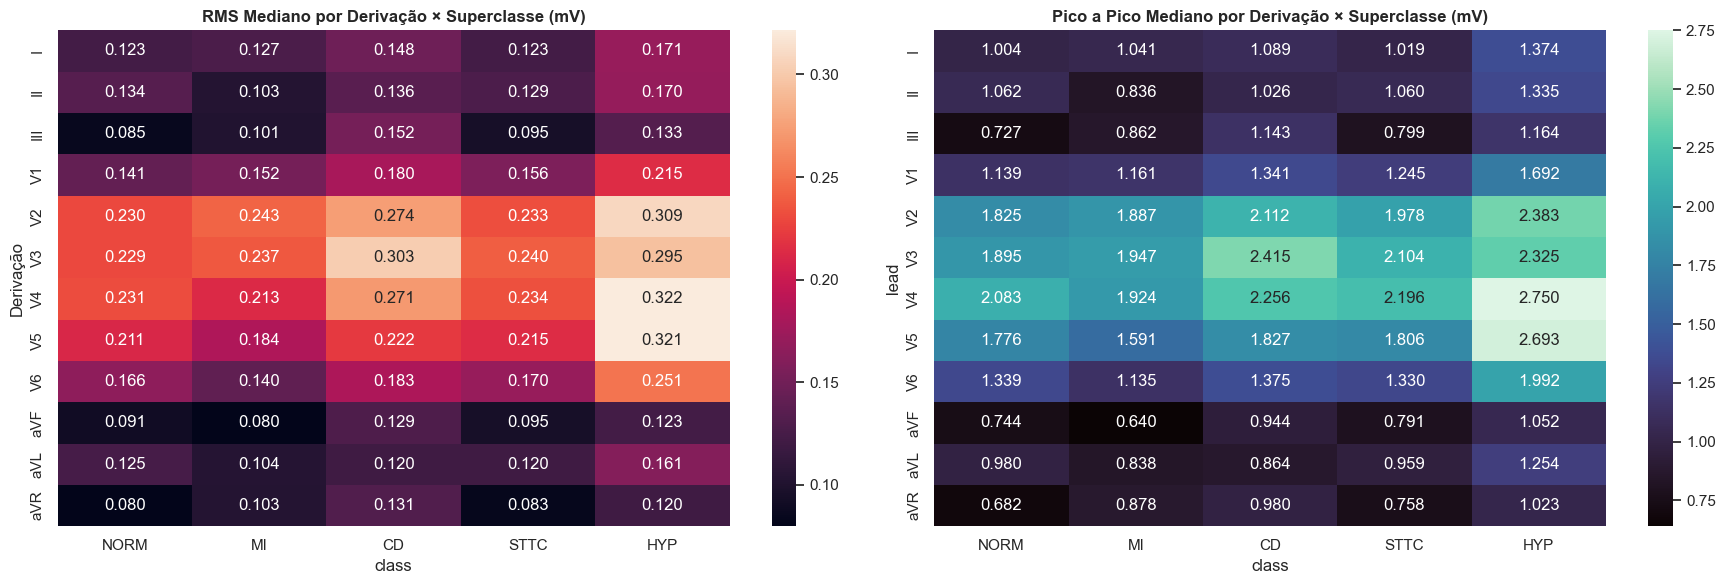

In [10]:
# Plot da Análise de Amplitude

# -------------------------
# Preparar dados
# -------------------------

pivot_rms = (
    df_desc
    .groupby(['lead', 'class'])['rms']
    .median()
    .unstack()[classes_target]
)

pivot_p2p = (
    df_desc
    .groupby(['lead', 'class'])['p2p']
    .median()
    .unstack()[classes_target]
)

# -------------------------
# Plot
# -------------------------

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# RMS
sns.heatmap(
    pivot_rms,
    annot=True,
    cmap='rocket',
    fmt=".3f",
    ax=ax1
)
ax1.set_title('RMS Mediano por Derivação × Superclasse (mV)', fontweight='bold')
ax1.set_ylabel('Derivação')

# P2P
sns.heatmap(
    pivot_p2p,
    annot=True,
    cmap='mako',
    fmt=".3f",
    ax=ax2
)
ax2.set_title('Pico a Pico Mediano por Derivação × Superclasse (mV)', fontweight='bold')

plt.tight_layout()

fig.savefig(
    FIGS_DIR / 'amplitude_rms_p2p_superclasse.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

**Comentários sobre a subseção 2.1:**

A análise conjunta das métricas de **RMS** e **Pico a Pico (P2P)** evidencia padrões consistentes tanto entre derivações quanto entre superclasses diagnósticas, refletindo a organização fisiológica da atividade elétrica cardíaca.

De forma geral, observa-se que as derivações precordiais (**V2–V5**) apresentam os maiores valores de amplitude em todas as classes, tanto em termos de RMS quanto de P2P. Esse comportamento é esperado, uma vez que essas derivações estão mais alinhadas com o vetor principal de despolarização ventricular, captando sinais com maior intensidade. [Vídeo explicativo das 12 derivações](https://www.alilamedicalmedia.com/pt/-/galleries/images-videos-by-medical-specialties/cardiology-and-vascular-diseases/-/medias/4d57ce72-0d39-4525-b523-329941b9edcf-ecg-de-12-derivacoes-explicado-animacao-em-ingles)

Em contraste, derivações como **aVR, aVF e III** apresentam amplitudes significativamente menores, o que também é consistente com sua orientação elétrica menos favorável em relação ao eixo cardíaco.

Ao comparar as superclasses, destaca-se que a classe **HYP (hipertrofia)** apresenta sistematicamente os maiores valores de amplitude em praticamente todas as derivações. Esse resultado é fisiologicamente plausível, já que a hipertrofia ventricular está associada ao aumento da massa muscular cardíaca, resultando em maior magnitude dos potenciais elétricos registrados.

A classe **CD (distúrbios de condução)** também apresenta valores elevados, especialmente nas derivações precordiais, possivelmente refletindo alterações na propagação do impulso elétrico que aumentam a dispersão e a amplitude dos sinais.

Por outro lado, as classes **NORM** e **STTC** tendem a apresentar amplitudes intermediárias e mais estáveis, enquanto **MI (infarto do miocárdio)** apresenta, em alguns casos, redução de amplitude em determinadas derivações, o que pode estar associado à perda de tecido viável e consequente diminuição da atividade elétrica local.

Por fim, nota-se uma forte coerência entre as métricas de RMS e P2P: regiões com maior RMS também apresentam maiores valores de P2P, indicando consistência na representação da amplitude do sinal. No entanto, o P2P apresenta maior sensibilidade a variações extremas, evidenciando diferenças mais pronunciadas entre classes em algumas derivações.

Em conjunto, esses resultados demonstram que as métricas de amplitude capturam de forma eficaz tanto a **estrutura fisiológica do ECG** quanto **diferenças relevantes entre condições cardíacas**, constituindo uma base sólida para a caracterização inicial dos sinais.

### 2.2 Energia do Sinal

Nesta subseção, analisamos o **conteúdo energético global dos sinais de ECG**, com o objetivo de complementar a análise de amplitude realizada anteriormente.

A energia do sinal foi calculada como a **soma dos quadrados das amplitudes ao longo do tempo, normalizada pelo número de amostras**, sendo definida como:

- **Energia total:**  
  Representa a **intensidade acumulada da atividade elétrica cardíaca** ao longo de todo o registro.

---

### Interpretação da Métrica

Diferentemente das métricas de amplitude (RMS e P2P), que avaliam a magnitude instantânea do sinal, a energia incorpora simultaneamente:

- **Amplitude**
- **Duração**
- **Distribuição temporal da atividade elétrica**

Dessa forma, a energia pode ser interpretada como uma medida mais global do “esforço elétrico” do coração ao longo do exame.

---

### Análise por Superclasse

A análise da energia foi realizada em nível de **registro completo**, permitindo comparar diretamente o comportamento global do sinal entre as diferentes superclasses diagnósticas.

Espera-se que condições associadas a maior atividade elétrica cardíaca, como **hipertrofia (HYP)**, apresentem valores mais elevados de energia, enquanto sinais com menor amplitude ou regiões eletricamente inativas podem apresentar valores reduzidos.

---

### Considerações Gerais

A métrica de energia complementa a análise de amplitude ao fornecer uma visão integrada do sinal ao longo do tempo. Enquanto RMS e P2P capturam características locais e instantâneas, a energia permite avaliar o **comportamento global do ECG**, sendo particularmente útil para identificar diferenças estruturais entre classes.

Essa abordagem contribui para uma caracterização mais completa dos sinais, preparando o terreno para análises posteriores de variabilidade e morfologia.

### Estatísticas da Energia por Superclasse

,mediana,media,std,min,max
class,,,,,
NORM,0.362,0.411,0.260,0.115,4.081
MI,0.354,0.442,0.359,0.095,3.461
CD,0.597,1.145,1.461,0.088,15.714
STTC,0.380,0.450,0.312,0.099,4.610
HYP,0.754,0.858,0.610,0.167,8.375


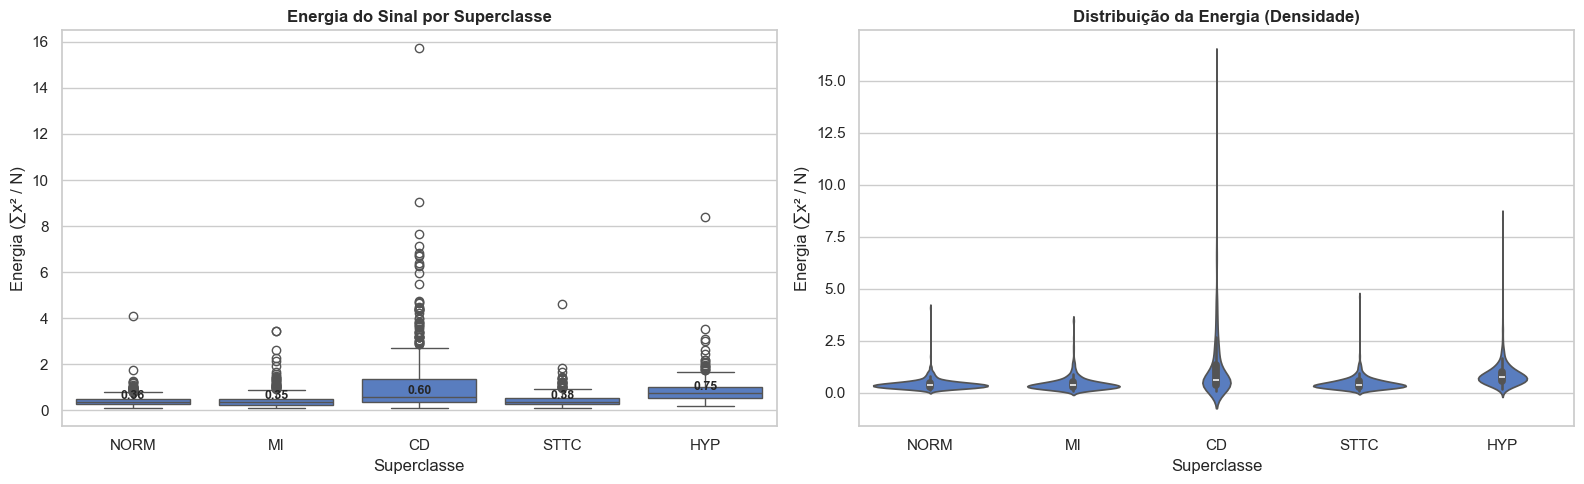

In [11]:
# Plot da Energia de Sinal
 
# -------------------------
# Preparar dados
# -------------------------

df_plot = df_energ.copy()

# garantir ordem das classes
df_plot['class'] = pd.Categorical(df_plot['class'], categories=classes_target, ordered=True)

# -------------------------
# Plot
# -------------------------

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# -------------------------
# 1. Boxplot (distribuição)
# -------------------------


sns.boxplot(
    data=df_plot,
    x='class',
    y='energia',
    order=classes_target,
    ax=axes[0]
)

axes[0].set_title('Energia do Sinal por Superclasse', fontweight='bold')
axes[0].set_xlabel('Superclasse')
axes[0].set_ylabel('Energia (∑x² / N)')

# -------------------------
# 2. Violin plot (densidade)
# -------------------------

sns.violinplot(
    data=df_plot,
    x='class',
    y='energia',
    order=classes_target,
    ax=axes[1]
)

axes[1].set_title('Distribuição da Energia (Densidade)', fontweight='bold')
axes[1].set_xlabel('Superclasse')
axes[1].set_ylabel('Energia (∑x² / N)')

# -------------------------
# Estatísticas (mediana)
# -------------------------

medianas = df_plot.groupby('class')['energia'].median()

for i, c in enumerate(classes_target):
    val = medianas[c]
    axes[0].text(i, val, f'{val:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# -------------------------
# Tabela ( medianas + estatísticas)
# -------------------------

stats_energia = df_plot.groupby('class')['energia'].agg([
    ('mediana', 'median'),
    ('media', 'mean'),
    ('std', 'std'),
    ('min', 'min'),
    ('max', 'max')
]).round(3)

display(Markdown("### Estatísticas da Energia por Superclasse"))
display(stats_energia)

# -------------------------
# Final
# -------------------------

plt.tight_layout()

fig.savefig(
    FIGS_DIR / 'energia_por_superclasse.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

**Comentários sobre a subseção 2.2:**

A análise da energia do sinal evidencia diferenças relevantes entre as superclasses, reforçando e expandindo os achados observados na análise de amplitude.

De forma geral, observa-se que a classe **HYP (hipertrofia)** apresenta a **maior mediana de energia (0.754)**, o que é consistente com o aumento da massa miocárdica e, consequentemente, maior atividade elétrica global. Esse comportamento já havia sido sugerido pelos valores elevados de RMS e P2P, sendo agora confirmado sob uma perspectiva integrada ao longo do tempo.

A classe **CD (distúrbios de condução)** também se destaca, com mediana elevada (0.597), mas principalmente por apresentar **alta variabilidade (desvio padrão de 1.461)** e valores máximos extremamente altos (até 15.714). Esse padrão sugere grande heterogeneidade nos sinais dessa classe, possivelmente refletindo diferentes tipos e graus de alterações na condução elétrica, que impactam de forma desigual o conteúdo energético do ECG.

As classes **NORM**, **MI** e **STTC** apresentam valores de energia relativamente próximos entre si, com medianas na faixa de 0.35–0.38. No entanto, a classe **MI (infarto do miocárdio)** apresenta leve aumento na média (0.442) e maior dispersão, indicando que, embora muitos sinais sejam semelhantes aos normais em termos de energia global, há casos com maior intensidade elétrica — possivelmente associados a alterações morfológicas específicas.

De maneira geral, a energia do sinal se mostra uma métrica eficaz para capturar diferenças globais entre classes, especialmente em condições associadas a alterações estruturais do coração. Além disso, a presença de caudas longas (valores máximos elevados) em algumas classes reforça a importância de considerar não apenas medidas centrais, mas também a variabilidade e a distribuição completa dos dados.

---

###  2.3 Variabilidade do Sinal

Além da análise de amplitude e energia, é fundamental caracterizar a **variabilidade do sinal de ECG**, que reflete o grau de dispersão das amplitudes ao longo do tempo.

Diferentemente do RMS, que mede a magnitude global da atividade elétrica, o **desvio padrão (STD)** captura o quanto o sinal oscila em torno de sua média, sendo sensível tanto à morfologia dos complexos cardíacos quanto à presença de variações ao longo do traçado.

---

### Fundamentação

Em sinais fisiológicos, a variabilidade está associada a múltiplos fatores, incluindo:

- Dinâmica dos complexos QRS  
- Presença de ondas P e T bem definidas  
- Variações no ritmo cardíaco  
- Alterações estruturais do miocárdio  

Sinais com maior variabilidade tendem a apresentar **maior riqueza morfológica**, enquanto sinais mais estáveis podem indicar menor atividade elétrica ou traçados mais uniformes.

---

### Abordagem Experimental

A análise foi conduzida utilizando o **desvio padrão por derivação**, agregando os resultados por superclasse diagnóstica.

Foram utilizadas duas estratégias complementares:

- **Mapa de calor (mediana por derivação × classe):** permite identificar quais derivações apresentam maior variabilidade em cada condição clínica  
- **Boxplot por superclasse:** avalia a distribuição global da variabilidade entre as classes  

---

### Interpretação Esperada

Espera-se observar padrões consistentes com as análises anteriores:

- Classes como **HYP** e **CD** tendem a apresentar **maior variabilidade**, devido à maior amplitude e complexidade dos sinais  
- Classes como **NORM** tendem a apresentar variabilidade mais moderada e estável  
- Diferenças entre derivações podem refletir a orientação espacial da atividade elétrica cardíaca  

Essa análise complementa as anteriores ao fornecer uma visão da **dinâmica interna do sinal**, sendo especialmente útil para diferenciar padrões fisiológicos de alterações estruturais ou funcionais.


### Estatísticas Globais do STD por Classe

,median,mean,std,min,max
class,,,,,
NORM,0.147,0.163,0.088,0.025,1.878
MI,0.138,0.163,0.101,0.022,1.698
CD,0.176,0.235,0.197,0.022,2.545
STTC,0.147,0.168,0.096,0.022,2.040
HYP,0.201,0.231,0.135,0.038,2.756


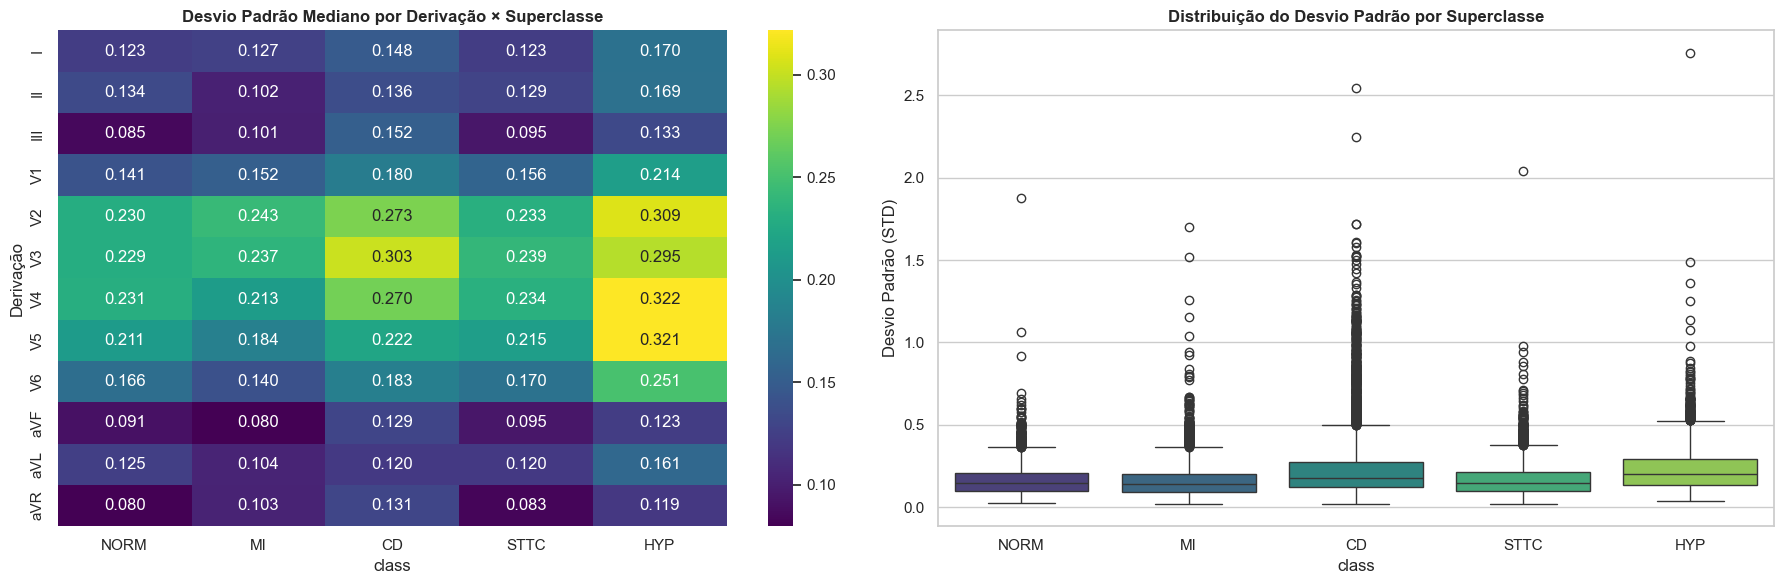

In [17]:
# Plot da Variabilidade do Sinal (STD)

# Pivot: média do desvio padrão por derivação × classe
pivot_std = (
    df_desc
    .groupby(['lead', 'class'])['std']
    .median()
    .unstack()[classes_target]
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# ──────────────────────────────────────────────
# Estatísticas globais por classe
# ──────────────────────────────────────────────
stats_std = (
    df_desc
    .groupby('class')['std']
    .agg(['median', 'mean', 'std', 'min', 'max'])
    .loc[classes_target]
)

display(Markdown("### Estatísticas Globais do STD por Classe"))
display(stats_std.round(3))

# -------------------------
# Heatmap (variabilidade por derivação)
# -------------------------
sns.heatmap(
    pivot_std,
    annot=True,
    cmap='viridis',
    fmt=".3f",
    ax=ax1
)

ax1.set_title('Desvio Padrão Mediano por Derivação × Superclasse', fontweight='bold')
ax1.set_ylabel('Derivação')

# -------------------------
# Boxplot (variabilidade global)
# -------------------------
sns.boxplot(
    data=df_desc,
    x='class',
    y='std',
    order=classes_target,
    hue = 'class',
    palette='viridis',
    ax=ax2
)

ax2.set_title('Distribuição do Desvio Padrão por Superclasse', fontweight='bold')
ax2.set_ylabel('Desvio Padrão (STD)')

plt.tight_layout()
fig.savefig(FIGS_DIR / 'variabilidade_std_superclasse.png', dpi=150, bbox_inches='tight')
plt.show()

**Comentários sobre a subseção 2.3:**

A análise da variabilidade do sinal, medida pelo desvio padrão (STD), apresenta um padrão altamente consistente com os resultados observados nas métricas de amplitude (RMS e P2P), o que era esperado, dado que todas capturam, sob diferentes perspectivas, a magnitude das oscilações do ECG.

De forma geral, as derivações precordiais (V1–V6) exibem maior variabilidade em todas as classes, com destaque para V2–V4, que concentram os maiores valores de STD. Esse comportamento reflete a maior sensibilidade dessas derivações à atividade elétrica ventricular, especialmente durante o complexo QRS.

Entre as superclasses, observa-se que:

- **HYP** apresenta os maiores valores de variabilidade em praticamente todas as derivações, com mediana global de 0.201. Esse resultado é coerente com o aumento da massa ventricular característico da hipertrofia, que se traduz em maior amplitude e, consequentemente, maior dispersão do sinal.
  
- **CD** também se destaca por apresentar variabilidade elevada (mediana = 0.176), além de maior dispersão global (std = 0.197), sugerindo maior heterogeneidade morfológica entre os registros dessa classe, possivelmente associada a distúrbios de condução e alterações no padrão de ativação elétrica.

- **NORM** e **STTC** apresentam comportamentos bastante semelhantes, com níveis intermediários de variabilidade, indicando sinais mais estáveis e com menor dispersão em relação às classes patológicas mais pronunciadas.

- **MI** apresenta variabilidade levemente inferior à classe NORM em algumas derivações, o que pode refletir a presença de áreas isquêmicas com redução da amplitude do sinal, especialmente em regiões afetadas.

Outro ponto relevante é a diferença entre mediana e média em classes como **CD** e **HYP**, indicando a presença de valores extremos (outliers, presença essa evidente pela densa e longa cauda dessas classes no boxplot), o que sugere que alguns registros apresentam variações muito mais intensas do que a maioria — um comportamento típico em bases clínicas reais.

De forma geral, a métrica de desvio padrão reforça os achados anteriores e contribui para a caracterização da **variabilidade intrínseca do sinal**, sendo particularmente útil para identificar classes com maior heterogeneidade e complexidade eletrofisiológica.

### 2.4 Caracterização Morfológica do Sinal

Nesta subseção, investigamos propriedades **estatísticas de ordem superior** do sinal de ECG, com foco em sua **forma de distribuição** ao longo do tempo. Diferentemente das análises anteriores — centradas em amplitude, energia e variabilidade — aqui buscamos compreender aspectos mais sutis da **morfologia do sinal**, especialmente relacionados à presença de picos e assimetrias.

As métricas utilizadas são:

- **Skewness (Assimetria):**  
  Mede o grau de assimetria da distribuição das amplitudes do sinal. Em ECGs fisiológicos, espera-se uma leve assimetria positiva devido à predominância da onda R (pico positivo). Alterações nesse padrão podem refletir mudanças morfológicas relevantes ou distorções estruturais.

- **Kurtosis (Curtose):**  
  Avalia o grau de concentração dos valores em torno da média, sendo altamente sensível à presença de picos acentuados. Sinais com complexos QRS bem definidos tendem a apresentar maior curtose, enquanto sinais mais “achatados” ou suavizados apresentam valores menores.

---

### Reutilização das Métricas de SQI

Embora **skewness** e **kurtosis** já tenham sido utilizadas anteriormente na composição do índice **hosSQI**, sua inclusão nesta etapa possui um objetivo distinto.

- No contexto de SQI:  
  → são utilizadas para **detecção de degradação e ruído**, compondo um índice de qualidade do sinal  

- Nesta subseção:  
  → são analisadas **individualmente**, com o objetivo de caracterizar a **morfologia intrínseca do ECG**

Ou seja, a reutilização dessas métricas é justificada pela diferença de propósito: aqui elas deixam de ser indicadores de qualidade e passam a atuar como **descritores estatísticos do formato do sinal**.

---

### Estratégia de Análise

A análise será conduzida em dois níveis:

- **Por derivação:**  
  Avaliação da mediana de skewness e kurtosis para cada derivação, permitindo identificar diferenças morfológicas entre regiões cardíacas (ex: precordiais vs periféricas)

- **Por superclasse diagnóstica:**  
  Análise agregada (mediana, média, dispersão) para investigar possíveis padrões associados a condições clínicas distintas

---

### Interpretação Esperada

- **Skewness:**
  - Valores positivos → predominância de picos positivos (esperado em ECG normal)
  - Valores próximos de zero → distribuição mais simétrica
  - Valores negativos → possíveis inversões ou alterações morfológicas

- **Kurtosis:**
  - Valores elevados → presença de picos acentuados (QRS bem definido)
  - Valores baixos → sinal mais suavizado ou disperso
  - Valores muito altos → possível presença de outliers ou eventos extremos

---

Essa análise complementa as subseções anteriores ao fornecer uma visão mais refinada da **estrutura estatística do sinal**, permitindo identificar diferenças morfológicas entre classes diagnósticas que não são capturadas apenas por métricas de amplitude ou energia.

### Estatísticas de Skewness por classe

,median,mean,std,min,max
class,,,,,
CD,0.159,0.184,2.468,-8.377,8.828
HYP,1.868,0.993,3.335,-6.618,8.294
MI,0.577,0.408,3.113,-13.980,14.046
NORM,1.629,0.921,2.963,-7.540,6.272
STTC,1.528,0.861,3.192,-6.507,7.303


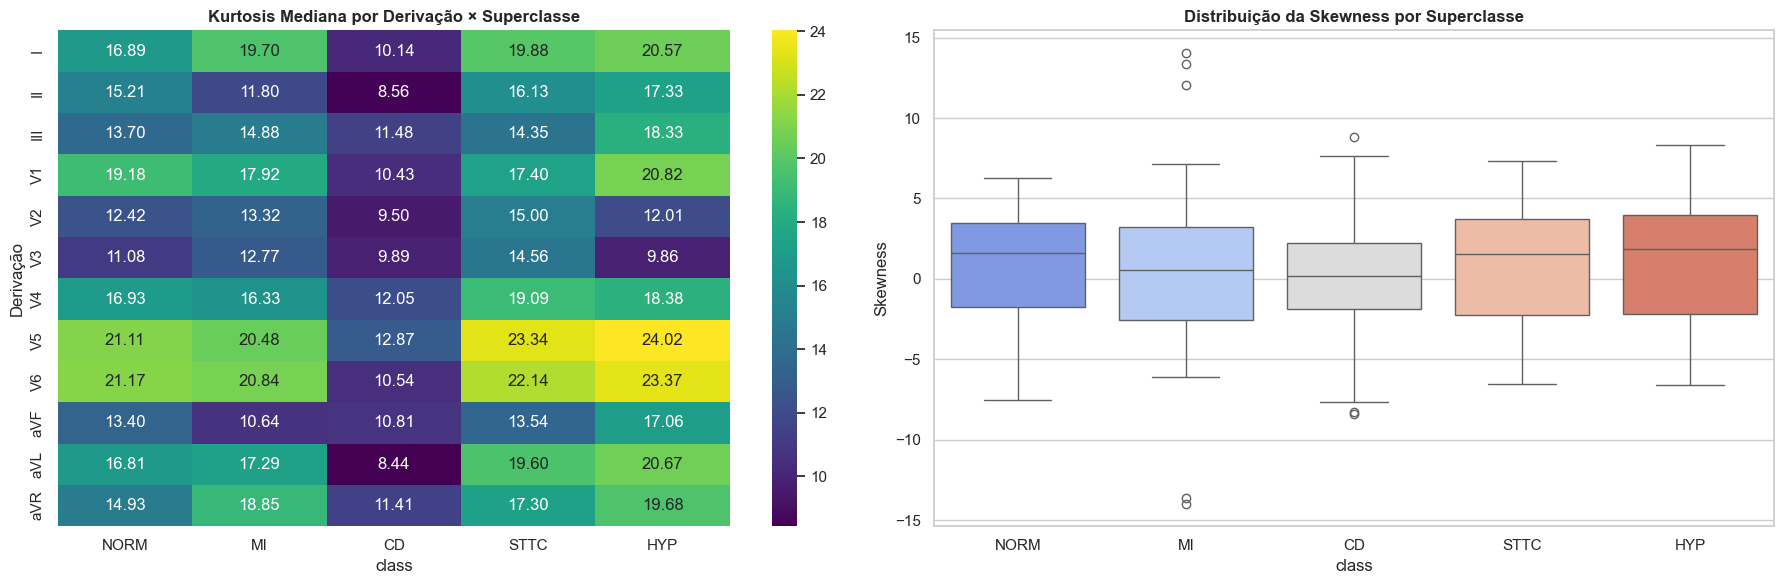

In [22]:
# Plot da caracterização morfológica dos sinais

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

pivot_kurt = (
    df_desc
    .groupby(['lead', 'class'])['kurt']
    .median()
    .unstack()[classes_target]
)

# ──────────────────────────────────────────────
# Estatísticas — Skewness por classe
# ──────────────────────────────────────────────
skew_stats = (
    df_desc
    .groupby('class')['skew']
    .agg(['median', 'mean', 'std', 'min', 'max'])
)

display(Markdown("### Estatísticas de Skewness por classe"))
display(skew_stats.round(3))

# ──────────────────────────────────────────────
# Heatmap — Kurtosis mediana por derivação × classe
# ──────────────────────────────────────────────
sns.heatmap(
    pivot_kurt,
    annot=True,
    fmt=".2f",
    cmap='viridis',
    ax=ax1
)

ax1.set_title('Kurtosis Mediana por Derivação × Superclasse', fontweight='bold')
ax1.set_ylabel('Derivação')

# ──────────────────────────────────────────────
# Boxplot — Skewness por classe
# ──────────────────────────────────────────────
sns.boxplot(
    data=df_desc,
    x='class',
    y='skew',
    order=classes_target,
    hue='class',
    palette='coolwarm',
    ax=ax2
)

ax2.set_title('Distribuição da Skewness por Superclasse', fontweight='bold')
ax2.set_ylabel('Skewness')

plt.tight_layout()

fig.savefig(
    FIGS_DIR / 'morfologia_sinal.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

**Comentários sobre a subseção 2.4:**

A análise das métricas de **kurtosis** e **skewness** fornece uma visão mais profunda da **morfologia estatística dos sinais de ECG**, complementando as análises anteriores de amplitude e variabilidade.

Observando a **kurtosis**, nota-se que todas as classes apresentam valores elevados (tipicamente > 10), o que é esperado em sinais de ECG devido à presença de picos acentuados associados ao complexo QRS. No entanto, algumas diferenças estruturais emergem:

- As classes **HYP** e **STTC** tendem a apresentar **kurtosis mais elevada**, especialmente nas derivações precordiais (V5, V6), sugerindo sinais com picos mais pronunciados e concentrados — possivelmente associados a alterações na massa ventricular ou padrões de repolarização.
- A classe **CD** apresenta sistematicamente **menores valores de kurtosis**, indicando sinais mais “espalhados” e menos pontiagudos, o que pode refletir **alterações na condução elétrica** e morfologias mais complexas ou fragmentadas.
- As derivações **V5 e V6** destacam-se com os maiores valores de kurtosis em praticamente todas as classes, reforçando seu papel na captação da atividade ventricular esquerda, onde o QRS tende a ser mais dominante.

Em relação à **skewness**, os resultados indicam uma maior variabilidade entre classes:

- Classes como **HYP**, **NORM** e **STTC** apresentam **medianas positivas**, coerentes com a assimetria esperada de sinais de ECG, onde a onda R (positiva) predomina.
- A classe **MI** apresenta valores mais próximos de zero e maior dispersão, sugerindo **maior heterogeneidade morfológica**, o que é consistente com diferentes padrões de infarto (localização, extensão, fase evolutiva).
- A classe **CD** novamente se destaca por valores de skewness mais baixos, indicando sinais mais simétricos ou menos definidos, possivelmente associados a distúrbios de condução que “suavizam” a morfologia típica do ECG.

Outro ponto relevante é a **alta variabilidade (STD elevado)** observada em todas as classes (em especial em MI, CD e ), com presença de valores extremos (mínimos e máximos bastante distantes), indicando que essas métricas são **sensíveis a outliers e variações individuais**, o que é esperado em dados clínicos reais.

De forma geral, essas métricas reforçam que:

- **Kurtosis** captura a intensidade e nitidez dos complexos QRS  
- **Skewness** reflete a assimetria e predominância morfológica do sinal  

E, mais importante, mostram que diferentes condições clínicas não apenas alteram a amplitude do ECG, mas também sua **forma estatística**, evidenciando padrões distintos entre as superclasses diagnósticas.

---

## Seção 3 — Testes de Normalidade

A suposição de **normalidade** (distribuição gaussiana) é um pressuposto fundamental de muitos testes estatísticos clássicos, como ANOVA, teste t de Student e correlação de Pearson. Verificar formalmente essa suposição é indispensável para garantir que os testes aplicados nos entregáveis seguintes sejam estatisticamente válidos.

Em datasets grandes e biomédicos, a normalidade é frequentemente violada: variáveis como idade tendem a ser assimétrias (skewed) e métricas de sinal como amplitude RMS podem apresentar caudas pesadas pela presença de outliers clínicos.

Utilizamos dois testes complementares:

| Teste | Hipótese Nula (H₀) | Melhor para |
|---|---|---|
| **Shapiro-Wilk (SW)** | Dados seguem distribuição normal | Amostras pequenas (n < 5.000) — mais poderoso |
| **Kolmogorov-Smirnov (K-S)** | Dados seguem distribuição normal | Amostras grandes — mais conservador |

Em ambos os testes, **p < 0,05 leva à rejeição de H₀**, indicando que a distribuição não é normal com 95% de confiança.

### 3.1 Shapiro-Wilk e Kolmogorov-Smirnov

Aplicamos os dois testes em subamostras das variáveis de interesse, combinando variáveis de metadados e de sinal. O Shapiro-Wilk é executado com limite de 5.000 observações por restrição do algoritmo.

In [ ]:
amostra_v = df[['age_clean', 'weight', 'height']].dropna().sample(
    n=min(5000, len(df)), random_state=42
)

vars_teste = {
    'Idade'       : amostra_v['age_clean'].values,
    'Peso'        : amostra_v['weight'].dropna().values,
    'Altura'      : amostra_v['height'].dropna().values,
    'RMS DII'     : df_amp[df_amp['lead'] == 'II']['rms'].values,
    'Energia total': df_energ['energia'].values
}

linhas_teste = []
for nome, valores in vars_teste.items():
    v = valores[~np.isnan(valores)]
    if len(v) < 3:
        continue

    # Shapiro-Wilk (limitado a 5.000 obs. pelo algoritmo)
    stat_sw, p_sw = stats.shapiro(v[:5000])

    # Kolmogorov-Smirnov contra distribuição normal com mesmos parâmetros
    stat_ks, p_ks = stats.kstest(v, 'norm', args=(np.mean(v), np.std(v)))

    linhas_teste.append({
        'Variável'                   : nome,
        'Shapiro W'                  : round(stat_sw, 4),
        'p (SW)'                     : "< 0.001" if p_sw < 0.001 else round(p_sw, 4),
        'Rejeita normalidade (SW)?'  : "Sim" if p_sw < 0.05 else "Não",
        'K-S stat'                   : round(stat_ks, 4),
        'p (K-S)'                    : "< 0.001" if p_ks < 0.001 else round(p_ks, 4),
        'Rejeita normalidade (K-S)?': "Sim" if p_ks < 0.05 else "Não"
    })

df_testes_norm = pd.DataFrame(linhas_teste).set_index('Variável')
display(Markdown("**Resultados dos testes de normalidade:**"))
display(df_testes_norm)

### 3.2 Q-Q Plots (Quantile-Quantile)

O Q-Q plot compara os quantis observados de uma variável com os quantis teóricos de uma distribuição normal. Se os pontos caem sobre a linha diagonal, a variável segue aproximadamente uma distribuição normal. **Desvios sistemáticos revelam o tipo de afastamento da normalidade:**

- **Curvatura em S:** distribuição com caudas mais pesadas (leptocúrtica) ou mais leves (platocúrtica) que a normal.
- **Desvio upward na cauda direita:** assimetria positiva (skewness > 0), típico de variáveis como peso ou RMS.
- **Desvio downward na cauda esquerda:** assimetria negativa.

In [ ]:
fig, axes = plt.subplots(1, len(vars_teste), figsize=(4 * len(vars_teste), 4))

for i, (nome, valores) in enumerate(vars_teste.items()):
    v = valores[~np.isnan(valores)]
    stats.probplot(v, dist="norm", plot=axes[i])
    axes[i].set_title(f'Q-Q: {nome}', fontsize=10)
    axes[i].grid(alpha=0.3)

plt.suptitle('Q-Q Plots: desvios da linha diagonal indicam afastamento da normalidade', fontsize=11, y=1.02)
plt.tight_layout()
fig.savefig(FIGS_DIR / 'qq_plots.png', dpi=150, bbox_inches='tight')
plt.show()

**Comentários sobre a subseção 3.2:**

(conclusões dos gráficos)

---

## Seção 4 — Testes de Homocedasticidade

**Homocedasticidade** significa que a variância de uma variável é aproximadamente igual entre todos os grupos comparados. É o segundo pressuposto (após normalidade) dos testes paramétricos clássicos como ANOVA. Mesmo quando os dados não são normais, verificar homocedasticidade é importante pois:

- Indica se os grupos diferem não apenas em nível central (média/mediana) mas também em dispersão.
- Determina qual versão de cada teste utilizar (ex: ANOVA padrão vs. Welch ANOVA).

### 4.1 Levene e Bartlett

| Teste | Pressuposto | Característica |
|---|---|---|
| **Levene** (baseado na mediana) | Não assume normalidade | **Robusto** — preferido quando normalidade é rejeitada |
| **Bartlett** | Assume normalidade | Mais poderoso quando dados são normais; sensível a desvios |

Para ambos, **H₀: variâncias são iguais entre os grupos**. Se p < 0,05, rejeitamos H₀ e concluímos que as variâncias são heterogêneas (**heterocedasticidade**).

In [ ]:
grupos_idade = [df_single[df_single['single_class'] == c]['age_clean'].dropna()
                for c in classes_target]
grupos_energ = [df_energ[df_energ['class'] == c]['energia'].dropna()
                for c in classes_target]
grupos_rms   = [df_amp[(df_amp['lead'] == 'II') & (df_amp['class'] == c)]['rms'].dropna()
                for c in classes_target]

linhas_h = []
metricas_hetero = {
    'Idade'       : grupos_idade,
    'Energia total': grupos_energ,
    'RMS DII'     : grupos_rms
}

for nome, grupos in metricas_hetero.items():
    stat_l, p_l = stats.levene(*grupos, center='median')
    stat_b, p_b = stats.bartlett(*grupos)
    linhas_h.append({
        'Variável'                  : nome,
        'Levene stat'               : round(stat_l, 4),
        'Levene p-valor'            : "< 0.001" if p_l < 0.001 else round(p_l, 4),
        'Homocedástica (Levene)?'   : 'Não' if p_l < 0.05 else 'Sim',
        'Bartlett stat'             : round(stat_b, 4),
        'Bartlett p-valor'          : "< 0.001" if p_b < 0.001 else round(p_b, 4),
        'Homocedástica (Bartlett)?': 'Não' if p_b < 0.05 else 'Sim'
    })

df_hetero = pd.DataFrame(linhas_h).set_index('Variável')
display(Markdown("**Resultados dos testes de homocedasticidade:**"))
display(df_hetero)

**Comentários sobre a subseção 4.1:**

(conclusões dos gráficos)

### 4.2 Tabela-Decisão Metodológica

Com base nos resultados de normalidade (Seção 3) e homocedasticidade (Seção 4.1), geramos automaticamente a **tabela-decisão** que define quais testes estatísticos devem ser utilizados em cada variável nos entregáveis subsequentes.

A lógica é:
- **Dados normais + variâncias homogêneas →** testes paramétricos.
- **Dados não-normais ou variâncias heterogêneas →** testes não-paramétricos.

Os testes não-paramétricos são baseados em **ranks** (posições ordenadas) e não fazem suposições sobre a forma da distribuição, sendo adequados para dados biomédicos reais.

In [ ]:
linhas_decisao = []

for var in df_testes_norm.index:
    eh_normal = df_testes_norm.loc[var, 'Rejeita normalidade (SW)?'] == 'Não'

    if var in df_hetero.index:
        eh_homo = df_hetero.loc[var, 'Homocedástica (Levene)?'] == 'Sim'
    else:
        eh_homo = None

    str_normal = 'Sim' if eh_normal else 'Não'
    str_homo   = 'Sim' if eh_homo else ('A verificar' if eh_homo is None else 'Não')

    if eh_normal and (eh_homo is None or eh_homo):
        teste_k = 'ANOVA'
        teste_2 = 't-test'
    else:
        teste_k = 'Kruskal-Wallis'
        teste_2 = 'Mann-Whitney U'

    linhas_decisao.append({
        'Variável'          : var,
        'Normal?'           : str_normal,
        'Homocedástica?'    : str_homo,
        'Teste K grupos'    : teste_k,
        'Teste 2 grupos'    : teste_2
    })

df_decisao = pd.DataFrame(linhas_decisao).set_index('Variável')

display(Markdown("**Tabela-decisão gerada dinamicamente a partir dos testes:**"))
display(df_decisao)

# Conclusão automática
n_nao_normais = sum(1 for l in linhas_decisao if l['Normal?'] == 'Não')
total_vars    = len(linhas_decisao)

display(Markdown(
    f"**Conclusão:** {n_nao_normais} de {total_vars} variáveis rejeitaram normalidade.  \n"
    "Como a maioria não é normal e as variâncias diferem entre classes diagnósticas, "
    "**testes não-paramétricos (Kruskal-Wallis, Mann-Whitney U) devem ser adotados** "
    "em todas as comparações entre grupos nos entregáveis seguintes."
))

**Comentários sobre a subseção 4.2:**

(conclusões sobre os gráficos/tabelas)

---


## Seção 5 — Análise de Correlação

### 5.1 Matrizes de Pearson e Spearman

A análise de correlação revela o grau de **associação linear ou monotônica** entre pares de variáveis. Identificar correlações fortes é fundamental por dois motivos:

1. **Interpretação clínica:** correlações entre variáveis demográficas e métricas do sinal podem revelar padrões fisiológicos relevantes (ex: se idade se correlaciona com n_superclasses, isso confirma que pacientes mais velhos tendem a ter mais comorbidades).
2. **Engenharia de features:** variáveis muito correlacionadas entre si são redundantes. Incluir pares altamente correlacionados em modelos de machine learning pode introduzir multicolinearidade, inflando a variância dos coeficientes e dificultando a interpretação.

Utilizamos dois métodos complementares:

| Método | Detecta | Pressuposto |
|---|---|---|
| **Pearson** | Relações **lineares** | Normalidade (aproximada) |
| **Spearman** | Relações **monotônicas** (inclui não-lineares) | Nenhum — baseado em ranks |

Como os dados não seguem distribuição normal (confirmado na Seção 3), a correlação de **Spearman é mais confiável** neste contexto. A de Pearson é incluída para comparação. As matrizes são plotadas como **triângulos inferiores** para evitar redundância visual.

In [ ]:
df_corr_base = df[['age_clean', 'sex', 'weight', 'height', 'n_superclasses', 'sqi_score']].copy()

# Adicionando RMS pivotado dos registros amostrados
df_rms_pivot = df_amp.pivot(index='ecg_id', columns='lead', values='rms')
df_rms_pivot = df_rms_pivot.rename(columns={l: f'RMS_{l}' for l in LEAD_NAMES})

df_corr = df_corr_base.join(df_rms_pivot).join(df_energ.set_index('ecg_id')['energia'])

corr_p = df_corr.corr(method='pearson')
corr_s = df_corr.corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(22, 9))

mask = np.triu(np.ones_like(corr_p, dtype=bool))
sns.heatmap(corr_p, mask=mask, cmap='icefire', center=0,
            ax=axes[0], annot=False, cbar_kws={'shrink': .8})
axes[0].set_title('Pearson — Correlações Lineares', fontweight='bold')

sns.heatmap(corr_s, mask=mask, cmap='vlag', center=0,
            ax=axes[1], annot=False, cbar_kws={'shrink': .8})
axes[1].set_title('Spearman — Correlações Monotônicas', fontweight='bold')

plt.suptitle('Matrizes de Correlação: variáveis demográficas × métricas de sinal', fontsize=13)
plt.tight_layout()
fig.savefig(FIGS_DIR / 'correlacoes_pearson_spearman.png', dpi=150, bbox_inches='tight')
plt.show()

**Comentários sobre a subseção 5.1:**

(conclusões sobre os gráficos)

---
## Seção 6 — Síntese e Conexão

Ao longo deste entregável, foi construído um panorama estatístico completo do dataset PTB-XL — após o filtro de qualidade do Entregável 2 — integrando análise descritiva de metadados, caracterização do sinal bruto, testes de hipótese formais e mapeamento de dependências entre variáveis.

### O que foi descoberto

**Perfil demográfico:** ...

**Amplitude e energia dos sinais:** ...

**Normalidade e homocedasticidade:** ...

**Correlações:** ...

---

### Decisão metodológica consolidada

...

---

### Conexão com o próximo entregável

Os resultados desta análise estabelecem a base metodológica para o **Entregável 4 (Limpeza e Correção dos Dados)**. O perfil estatístico aqui documentado — medianas, IQR e distribuição de amplitude por derivação — servirá como linha de base para a comparação obrigatória antes/depois da filtragem. Como todas as variáveis rejeitaram normalidade e homocedasticidade, a validação do efeito da limpeza deve utilizar **Wilcoxon signed-rank** em lugar do teste t pareado, e o effect size deve ser calculado com métricas robustas como a rank-biserial correlation. A tabela-decisão da Seção 4.2 permanece como referência sempre que uma comparação entre grupos for necessária nos entregáveis subsequentes.

Abaixo é salvo o .csv com os resultados obtidos nesse entregável:

In [ ]:
path_estat = OUT_DIR / 'estatistica_inicial_resultados.csv'

df_export = pd.concat([df_testes_norm, df_hetero], axis=1)
df_export.to_csv(path_estat)

display(Markdown(f"""
**Arquivo salvo:** `{path_estat}`

NameError: name 'df_testes_norm' is not defined